<a href="https://colab.research.google.com/github/yewonhn/My-AI-Lab/blob/main/5%EC%A3%BC%EC%B0%A8/05_diabetes_CL_RE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###분류
당뇨병(Outcome) 여부를 판가름 : 이진분류 <br>
y는 정답<br>
x는 그 외

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    # 분류: 결과는 0~1 사이의 '확률'이어야 하므로 sigmoid
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    # 분류: 이진 분류 전용 손실 함수
    loss='binary_crossentropy',
    # 분류: 몇 개나 맞혔는지 '정확도'를 봄
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# 학습 시작
model.fit(X_train, y_train, epochs=50, batch_size=10, validation_split=0.2)

# 평가
loss, acc = model.evaluate(X_test, y_test)
print(f"테스트 정확도: {acc:.4f}")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9206 - loss: 0.2159 - val_accuracy: 0.7317 - val_loss: 0.6248
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9206 - loss: 0.2176 - val_accuracy: 0.7480 - val_loss: 0.6025
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9328 - loss: 0.1968 - val_accuracy: 0.7236 - val_loss: 0.6229
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9369 - loss: 0.1954 - val_accuracy: 0.7317 - val_loss: 0.6179
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9389 - loss: 0.1893 - val_accuracy: 0.7236 - val_loss: 0.6326
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9470 - loss: 0.1869 - val_accuracy: 0.6992 - val_loss: 0.6220
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9348 - loss: 0.1964 - val_accuracy: 0.7398 - val_loss: 0.6223
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9369 - loss: 0.1872 - val_accuracy: 0.7317 - val_los

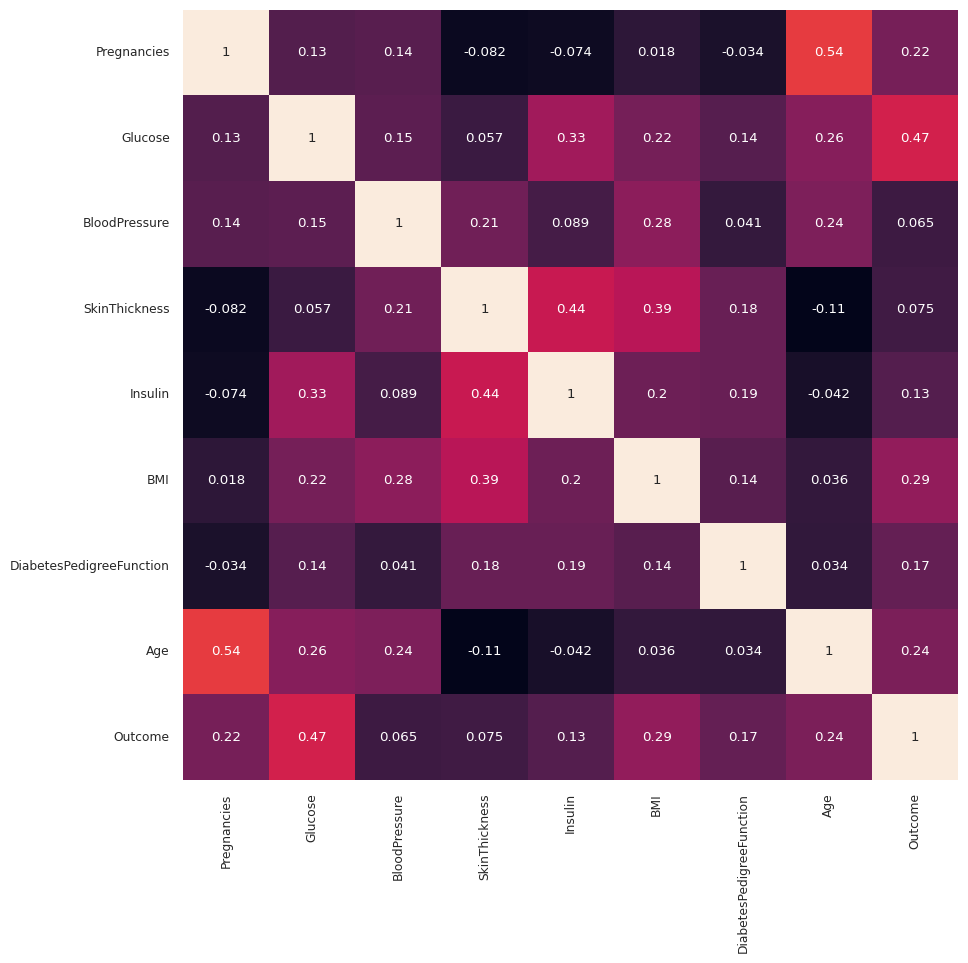

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

###회귀

포도당(Glucose) 수치를 예측. <br>
y는 포도당 수치<br>
x는 그 외



In [12]:
y_reg = df['Glucose']
X_reg = df.drop('Glucose', axis=1)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_reg.shape[1],)),
    Dense(32, activation='relu'),
    # 출력층: '포도당 수치'라는 숫자 하나를 내보내야 하므로 노드 1개, 마지막 활성화 함수 없음(분류는 있음)
    Dense(1)
])

model_reg.compile(
    optimizer='adam',
    loss='mse',          # 회귀의 표준 손실 함수
    metrics=['mae']      # 보기 편한 거
)

# 모델 구조 요약해서 보여주는 거
model_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 모델 학습
history_reg = model_reg.fit(
    X_train_reg, y_train_reg,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 610.4927 - mae: 18.7364 - val_loss: 792.8586 - val_mae: 21.0509
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 605.7524 - mae: 18.6642 - val_loss: 803.5193 - val_mae: 21.2092
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 611.7112 - mae: 18.6998 - val_loss: 797.0057 - val_mae: 21.1646
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 605.9621 - mae: 18.7825 - val_loss: 789.8043 - val_mae: 21.0557
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 603.2675 - mae: 18.6012 - val_loss: 793.7043 - val_mae: 21.0476
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 600.5765 - mae: 18.5605 - val_loss: 792.9485 - val_mae: 21.0260
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 602.6214 - mae: 18.5850 - val_loss: 789.4203 - val_mae: 21.0697
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 601.3584 - mae: 18.5639 - val_loss: 795.9947 - val_mae: 21.1761
Epoch 9/50
50/50 ━━━━━━━

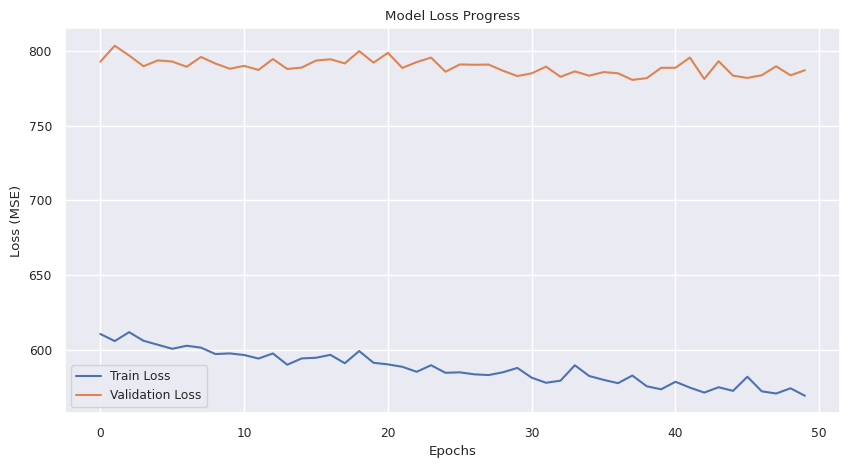

In [16]:
import matplotlib.pyplot as plt

# 학습 기록(history)을 그래프로 그리기
plt.figure(figsize=(10, 5))
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss') # 검증 오차
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()